In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep
import numpy as np
import pandas as pd
import uproot

from analysis.utils.colors import TangoColors
from analysis.utils.event_display import show_hist_plots, show_scatter_plots
from analysis.utils.geometry import Geometry, get_geometry, get_rebinned_geometry
from analysis.utils.plot_utils import add_legend, setup
from analysis.utils.preprocessing_utils import create_parquet_from_root, get_rebinned_df
from analysis.utils.truth import TruthParticle, get_truth_particle
from analysis.utils.units import um
from analysis.utils.utils import (
    get_color_from_pdg,
    get_label_from_pdg,
    get_parquet_path,
    get_root_path,
)

In [2]:
setup()

In [ ]:
run = 10026
chunk = 1
geometry_label = "200um_bins"

root_path = get_root_path() / f"{run:05d}/{run:05d}_{chunk:03d}.root"
traj = ak.to_dataframe(
    uproot.open(root_path)["trajectories"].arrays(library="ak"), how="outer"
)

In [66]:
traj.query("evtID == 1014").sort_values("trackKinE", ascending=False).head(10)

,evtID,trackTID,trackPID,trackPDG,trackKinE,trackNPoints,trackTheta
entry,,,,,,,
606,1014,1,0,15,408338.403593,16,0.023767
581,1014,2,0,22,244753.370329,5,0.009633
551,1014,4,0,111,238933.757351,2,0.011506
608,1014,1106159,1,-14,232642.501354,145,0.021813
530,1014,8,0,-211,219865.544543,12,0.010302
552,1014,265185,4,22,195694.928717,17,0.011241
607,1014,1106160,1,13,172409.341039,191,0.027108
554,1014,265186,265185,11,165188.472605,64,0.011244
582,1014,775583,2,-11,159775.381708,89,0.009634


In [62]:
traj.query("abs(trackPDG) == 13 & trackPID == 1")

,evtID,trackTID,trackPID,trackPDG,trackKinE,trackNPoints,trackTheta
entry,,,,,,,
128,1002,1192464,1,13,33648.347190,566,0.011449
607,1014,1106160,1,13,172409.341039,191,0.027108
1582,1041,70712,1,-13,42981.255639,244,0.067476
1646,1044,831225,1,13,19395.778788,363,0.005556
1650,1045,267,1,-13,27559.003935,196,0.021038
...,...,...,...,...,...,...,...
30249,1952,238276,1,-13,227925.038274,378,0.042151
30407,1964,3249,1,13,28164.626585,145,0.060662
30498,1968,523,1,-13,19738.266884,485,0.005398


In [72]:
traj.query("abs(trackPDG) == 11 & trackPID == 1")

,evtID,trackTID,trackPID,trackPDG,trackKinE,trackNPoints,trackTheta
entry,,,,,,,
899,1023,7569,1,-11,99182.792921,91,0.010490
986,1027,46777,1,11,158608.448362,107,0.012030
1400,1038,145608,1,11,245967.355222,55,0.019251
1518,1039,1045624,1,11,52713.427940,79,0.045954
1974,1052,978741,1,11,418253.385591,68,0.012770
...,...,...,...,...,...,...,...
30474,1965,1168105,1,11,24614.730141,43,0.033018
30494,1967,358,1,-11,13467.384649,52,0.016435
30681,1974,15516,1,-11,181063.069955,142,0.011384


In [60]:
traj.query("evtID == 1015")

,evtID,trackTID,trackPID,trackPDG,trackKinE,trackNPoints,trackTheta
entry,,,,,,,
609,1015,2,0,111,12292.912545,2,0.079381
610,1015,15514,2,22,10038.598998,5,0.084374
611,1015,1,0,-15,184439.839695,3,0.023360
612,1015,31981,1,-16,19092.845591,295,0.033080
613,1015,31980,1,211,78486.781364,22,0.023080
614,1015,32004,31980,2212,10944.952301,19,0.054254
615,1015,31979,1,211,77938.730294,113,0.023668
616,1015,80407,31979,111,14564.321599,2,0.030721
617,1015,80398,31979,111,19305.247813,2,0.016259


In [ ]:
run = 10026
chunk = 0
geometry_label = "200um_bins"

root_path = get_root_path() / f"{run:05d}/{run:05d}_{chunk:03d}.root"
parquet_hits_path = (
    get_parquet_path() / f"{run:05d}/{geometry_label}/{run:05d}_{chunk:03d}_hits.parq"
)
parquet_path = get_parquet_path() / f"{run:05d}/{geometry_label}"
parquet_truth_path = parquet_path / f"../{run:05d}_{chunk:03d}_truth.parq"
parquet_primaries_path = parquet_path / f"../{run:05d}_{chunk:03d}_primaries.parq"
faser_path = parquet_path / f"../{run:05d}_{chunk:03d}_faser.parq"
geometry_path = get_parquet_path() / f"{run:05d}/geometry.pkl"
geo_200um_path = get_parquet_path() / f"{run:05d}/muon_200um_bins/geometry_200um.pkl"

In [56]:
hits_df = pd.read_parquet(parquet_hits_path)
truth_df = pd.read_parquet(parquet_truth_path)
primaries_df = pd.read_parquet(parquet_primaries_path)
faser_df = pd.read_parquet(faser_path)
# geo = get_geometry(geo_path=geometry_path)
# geo_200um = get_rebinned_geometry(pixel_size=200 * um, old_geometry=geo)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tboeckh/Documents/faser/neutrino-detector/analysis/../data/parquet/10026/200um_bins/10026_001_hits.parq'

In [54]:
faser_df.query("nhits_0 > 0 & nhits_1 > 0 & nhits_2 > 0")[
    ["event_id", "pz_0", "pz_1", "pz_2", "faser_x", "faser_y"]
]

,event_id,pz_0,pz_1,pz_2,faser_x,faser_y
15,1015,77358.007812,77357.726562,77356.578125,97.186261,77.938842
38,1038,84172.937500,84172.671875,22083.843750,666.542098,83.732385
44,1044,176921.062500,176920.343750,176919.500000,69.059455,18.029631
50,1050,85462.265625,85459.062500,85455.117188,-8.927953,47.590086
54,1054,320089.062500,320088.000000,320087.750000,-13.135638,74.241330
...,...,...,...,...,...,...
934,1934,118316.304688,118315.750000,118314.929688,25.043860,-96.033038
937,1937,67346.492188,67349.046875,67350.695312,29.320493,63.426947
953,1953,195387.937500,195387.640625,54015.285156,479.600714,236.873839
968,1968,49582.171875,49581.312500,49581.007812,-91.283736,28.549660


In [52]:
primaries_df.query("event_id == 1015")

,event_id,trackID,pdg,E,px,py,pz
414,1015,1,-15,186216.703125,-3730.060547,2237.158936,186157.421875
415,1015,2,111,12427.892578,811.899109,-558.493835,12388.026367
416,1015,3,-211,533.844360,102.554893,-185.172409,469.791077
417,1015,4,111,3888.015869,471.552185,-80.628914,3856.110107
418,1015,5,211,1470.574829,102.367920,-385.449860,1408.566650
419,1015,6,111,7714.932129,1054.505737,-812.311584,7598.034180
420,1015,7,2112,3743.093994,767.878845,-363.783539,3522.213135
421,1015,8,-211,735.176880,133.896591,200.723267,680.284546
422,1015,9,211,1165.848022,182.989624,170.676285,1130.091187
423,1015,10,2112,1087.566284,-397.519501,-54.881516,-372.805084


In [31]:
primaries_df.query("(abs(pdg) == 11)  | (abs(pdg) == 13)")

,event_id,trackID,pdg,E,px,py,pz
19788,1717,3,-11,18023.968750,447.876556,828.649414,17999.337891
19789,1717,4,11,1874.504395,46.981499,83.295807,1872.063232


In [11]:
truth_df

,event_id,pdg_nu,vx,vy,vz,E_nu,pdg_lepton,E_lepton,px_lepton,py_lepton,pz_lepton
0,0,0,-93.481810,-69.579631,43.794203,0.0,15,1.791040e+05,-1449.695068,-2391.566406,1.790733e+05
1,1,0,-93.022115,48.638659,44.206135,0.0,-15,4.478754e+05,-5403.572266,520.222961,4.478390e+05
2,2,0,38.647428,-9.206169,40.330834,0.0,15,3.116314e+05,13150.359375,-12723.354492,3.110887e+05
3,3,0,-26.554416,0.304616,40.944653,0.0,15,9.854068e+03,499.985565,1703.838745,9.528503e+03
4,4,0,107.299107,-71.162344,40.778706,0.0,-15,9.006088e+05,1248.754395,-3823.701904,9.005981e+05
...,...,...,...,...,...,...,...,...,...,...,...
995,995,0,21.863415,21.660269,44.861896,0.0,15,4.498786e+04,1364.949463,1934.637207,4.489036e+04
996,996,0,58.763442,15.906055,44.853314,0.0,15,2.830812e+05,527.564209,433.124237,2.830748e+05
997,997,0,98.309693,-56.191321,42.275838,0.0,15,1.373377e+05,3573.534180,3668.583496,1.372307e+05
998,998,0,130.347132,-11.748766,41.519473,0.0,-15,1.298694e+05,-1516.253540,-2889.657471,1.298162e+05


## Event Displays


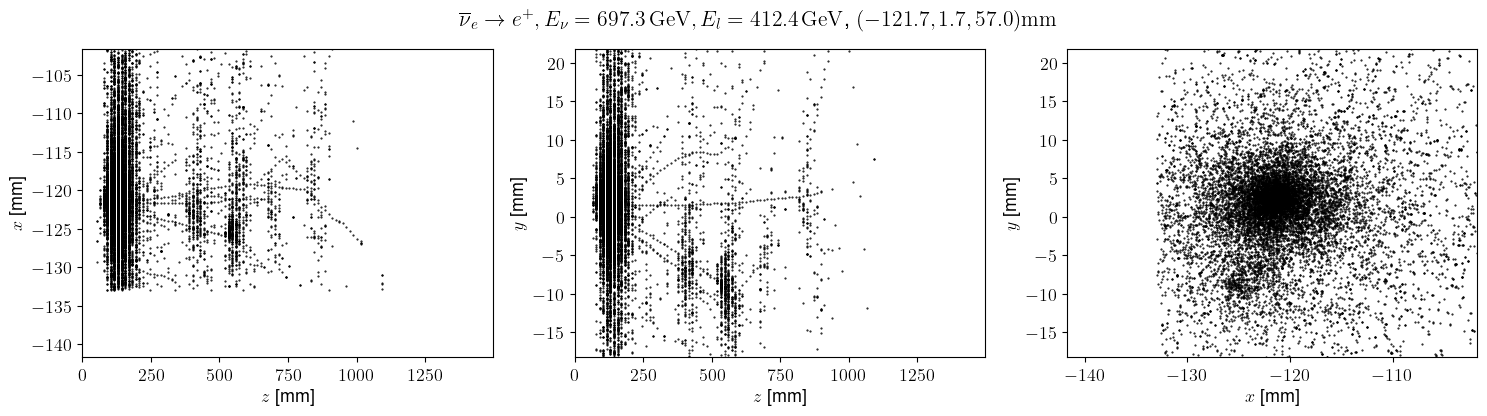

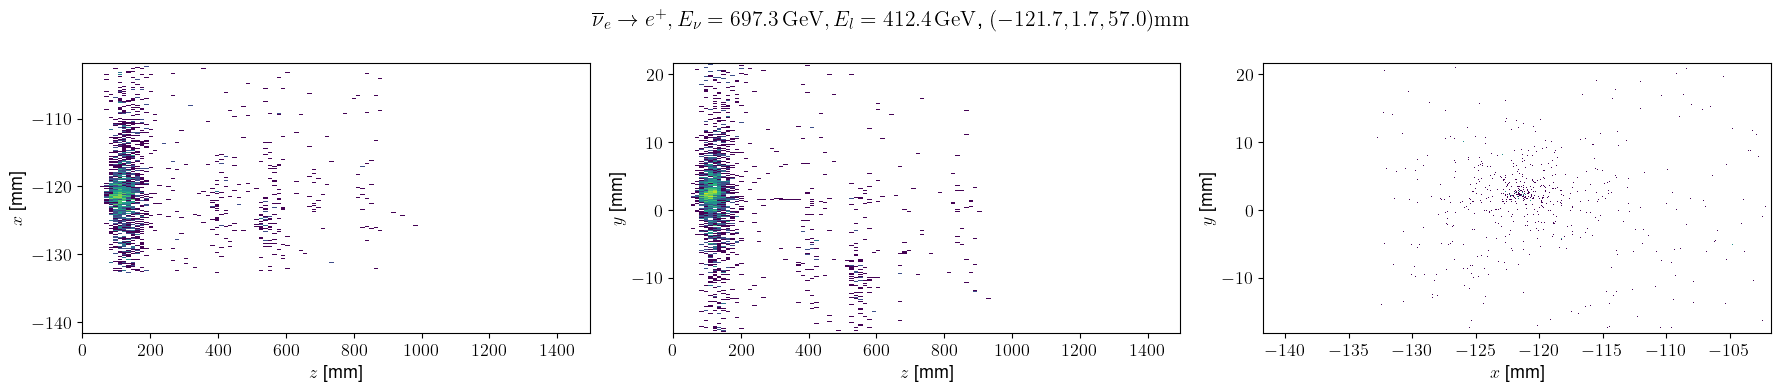

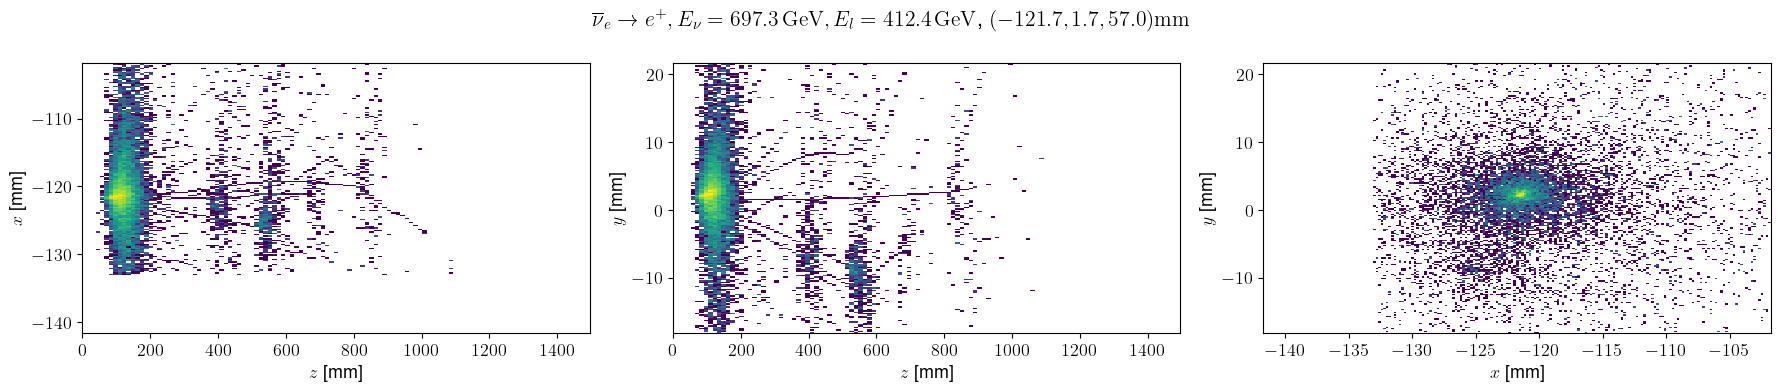

In [33]:
event_id = 0
event_hits = hits_df.query(f"event_id == {event_id}")
truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))
show_scatter_plots(df=event_hits, truth=truth, geo=geo, range=20)
show_hist_plots(df=event_hits, truth=truth, geo=geo, range=20)
show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=20)

## Particle labels


In [27]:
queries = [
    "(abs(hit_pdgc) == 11) & (hit_fromPrimaryEMShower == 1)",
    "(abs(hit_pdgc) == 11) & (hit_fromPrimaryEMShower == 0)",
    "(abs(hit_pdgc) == 13)",
    "(abs(hit_pdgc) != 11) & (abs(hit_pdgc) != 13)",
]
masks = [hits_df.eval(query) for query in queries]

colors = [
    TangoColors.scarlet_red,
    TangoColors.orange,
    TangoColors.chameleon,
    TangoColors.sky_blue,
]
labels = list(range(4))
latex_labels = [r"Primary $e^{\pm}$", r"Other $e^{\pm}$", r"$\mu^{\pm}$", r"Other"]

hits_df["color"] = "black"
hits_df["label"] = -1
for mask, color, label in zip(masks, colors, labels):
    hits_df.loc[mask, "label"] = label
    hits_df.loc[mask, "color"] = color

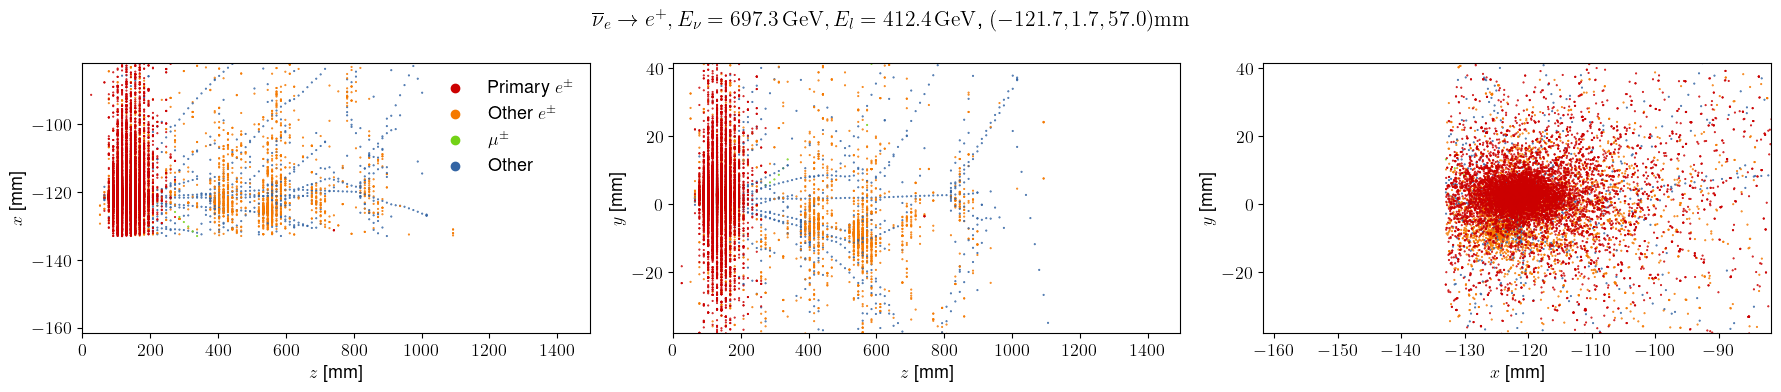

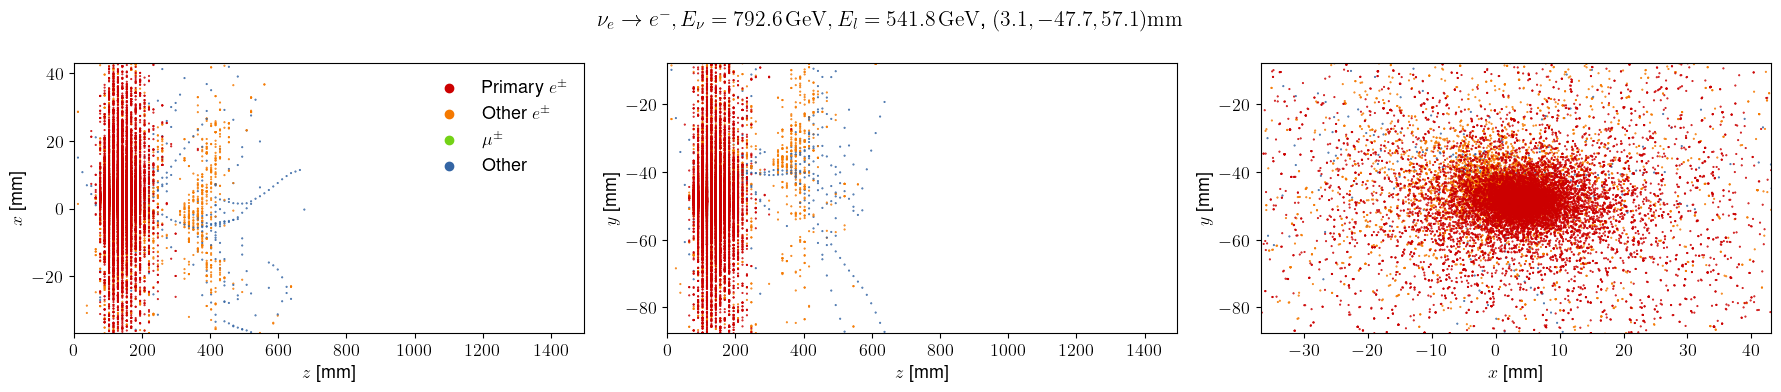

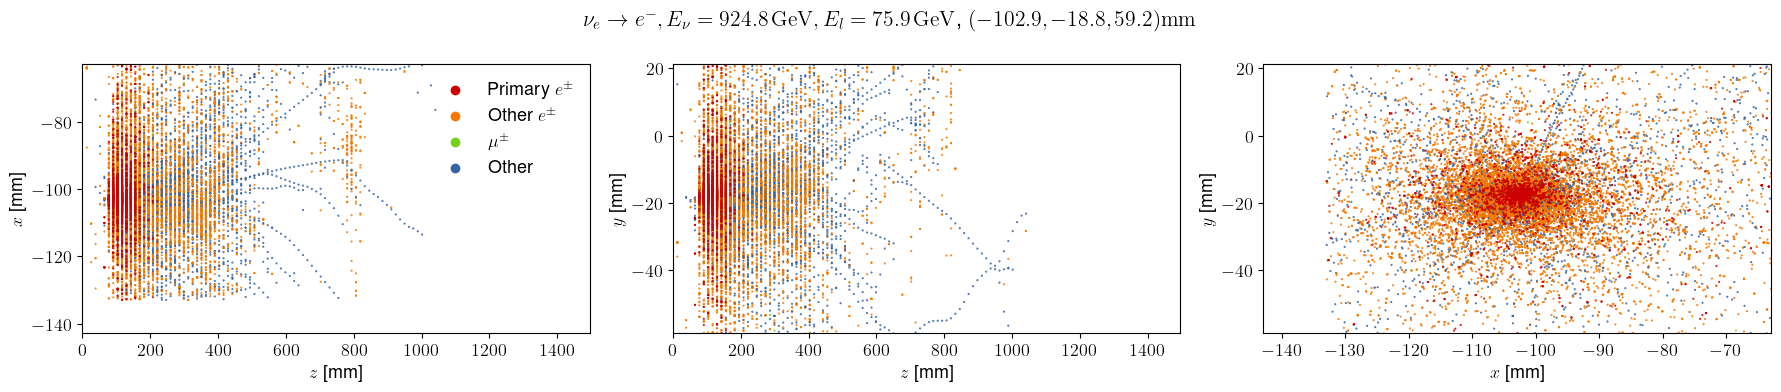

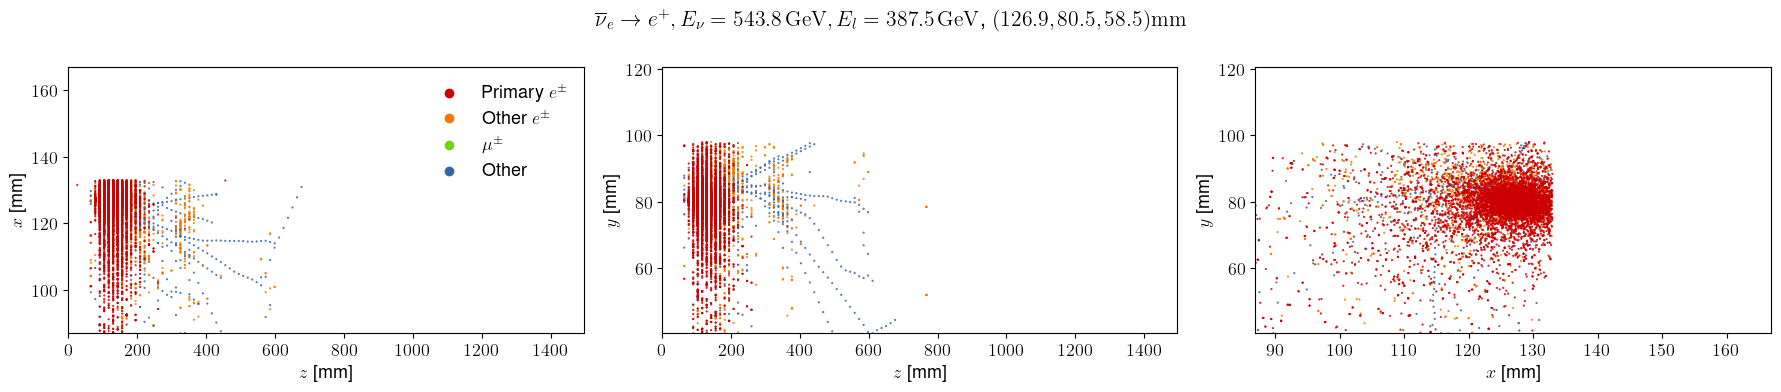

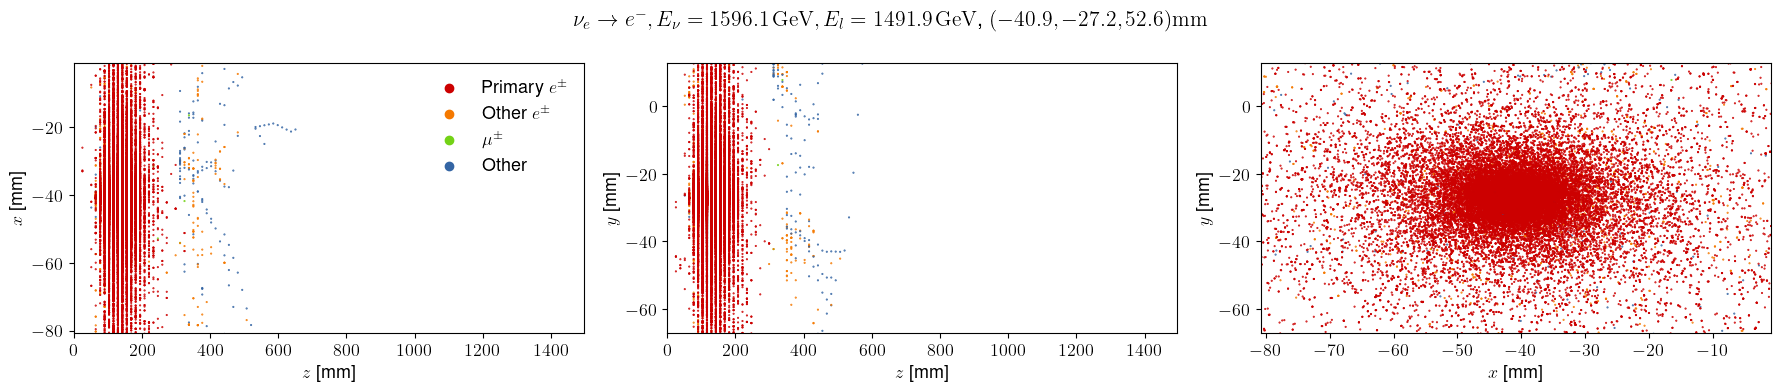

In [28]:
for event_id in range(5):
    plot_range = 40

    event_hits = hits_df.query(f"event_id == {event_id}")
    truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))

    fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
    fig.suptitle(truth.get_latex_title())
    show_scatter_plots(
        df=event_hits,
        truth=truth,
        geo=geo,
        range=plot_range,
        axs=axs,
        color=event_hits["color"].values,
    )
    for label, color in zip(latex_labels, colors):
        axs[0].scatter([], [], c=color, label=label)

    axs[0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=plot_range)

## Normalize events


In [20]:
rum = 10000
chunk = 0

parquet_200um_path = get_parquet_path() / f"{run:05d}/200um_bins"
parquet_hits_path = parquet_200um_path / f"{run:05d}_{chunk:03d}_hits.parq"
parquet_truth_path = parquet_200um_path / f"{run:05d}_{chunk:03d}_truth.parq"

hits_df = pd.read_parquet(parquet_hits_path)
truth_df = pd.read_parquet(parquet_truth_path)

In [21]:
hits_df.head()

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits,pdg_label,x,y,z
index,,,,,,,,,,
0,0,0,208,595,0.012590,1,1.0,-91.2,21.2,10.005
1,0,0,214,762,0.009982,1,1.0,-90.0,54.6,10.005
2,0,0,214,763,0.003272,1,1.0,-90.0,54.8,10.005
3,0,0,247,705,0.065258,1,0.0,-83.4,43.2,10.005
4,0,0,264,703,0.002662,1,1.0,-80.0,42.8,10.005


In [82]:
event_id = 2000
event_hits = hits_df.query(f"event_id == {event_id}")
truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))

In [83]:
event_hits.head()

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits,from_muon,from_electron,hit_label,x,y,z
index,,,,,,,,,,,,
0,2000,1,974,440,0.003548,1,False,True,2,62.0,-9.8,20.015
1,2000,2,527,807,0.014734,2,False,True,2,-27.4,63.6,30.025
2,2000,2,534,828,0.021739,2,False,True,2,-26.0,67.8,30.025
3,2000,4,990,750,0.012632,2,False,True,2,65.2,52.2,50.045
4,2000,4,1012,530,0.001744,1,False,False,0,69.6,8.2,50.045


In [65]:
features = event_hits[["x", "y", "z"]].values

In [66]:
mean_features = features.mean(axis=0)
std_features = features.std(axis=0)
norm_features = (features - mean_features) / std_features

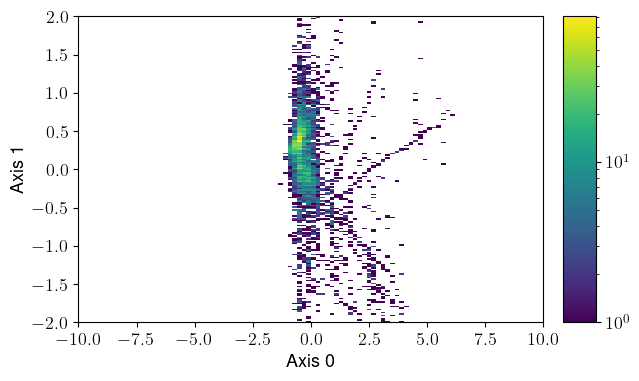

In [71]:
h = hist.Hist(hist.axis.Regular(100, -10, 10), hist.axis.Regular(200, -2, 2))
h.fill(norm_features[:, 2], norm_features[:, 0])
fig, ax = plt.subplots(figsize=(6, 4))
mplhep.hist2dplot(h, cmap="viridis", norm=mpl.colors.LogNorm(), ax=ax, flow=False)
plt.tight_layout()
plt.show()

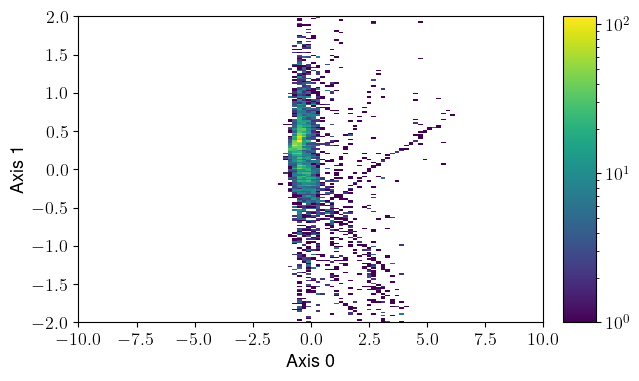

In [70]:
h = hist.Hist(
    hist.axis.Regular(100, -10, 10),
    hist.axis.Regular(200, -2, 2),
    storage=hist.storage.Weight(),
)
h.fill(norm_features[:, 2], norm_features[:, 0], weight=event_hits["n_hits"])
fig, ax = plt.subplots(figsize=(6, 4))
mplhep.hist2dplot(h, cmap="viridis", norm=mpl.colors.LogNorm(), ax=ax, flow=False)
plt.tight_layout()
plt.show()

## K nearest neighbours


In [23]:
from analysis.identify_hits.create_graph_data import create_event_graph

In [24]:
rum = 10000
chunk = 0

parquet_200um_path = get_parquet_path() / f"{run:05d}/200um_bins"
parquet_hits_path = parquet_200um_path / f"{run:05d}_{chunk:03d}_hits.parq"
parquet_truth_path = parquet_200um_path / f"{run:05d}_{chunk:03d}_truth.parq"

hits_df = pd.read_parquet(parquet_hits_path)
truth_df = pd.read_parquet(parquet_truth_path)

In [48]:
hits_df["n_hits_norm"] = np.log10(hits_df["n_hits"].values)

In [49]:
event_id = 0
event_hits = hits_df.query(f"event_id == {event_id}")
truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))

/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_hits.loc[:, "color"] = "blue"
/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(loc="upper right")


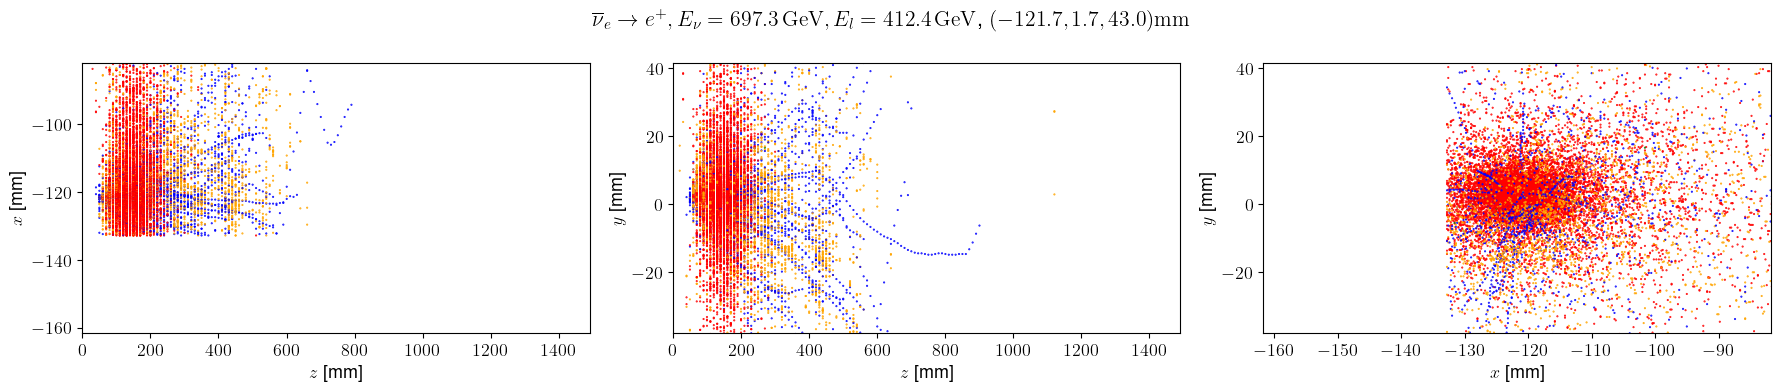

/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_hits.loc[:, "color"] = "blue"
/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(loc="upper right")


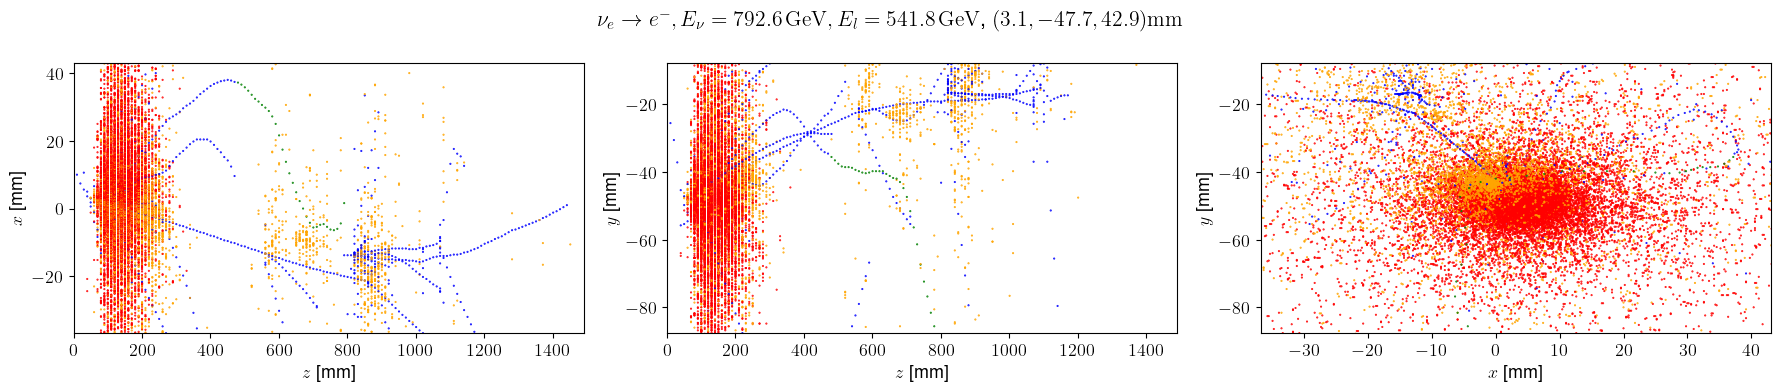

/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_hits.loc[:, "color"] = "blue"
/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(loc="upper right")


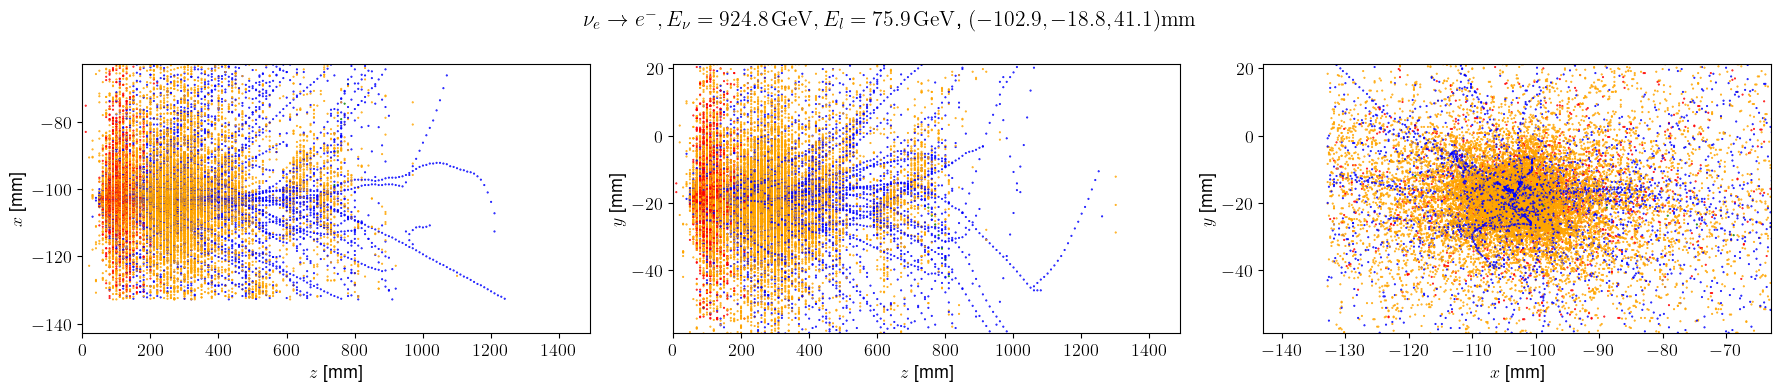

/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_hits.loc[:, "color"] = "blue"
/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(loc="upper right")


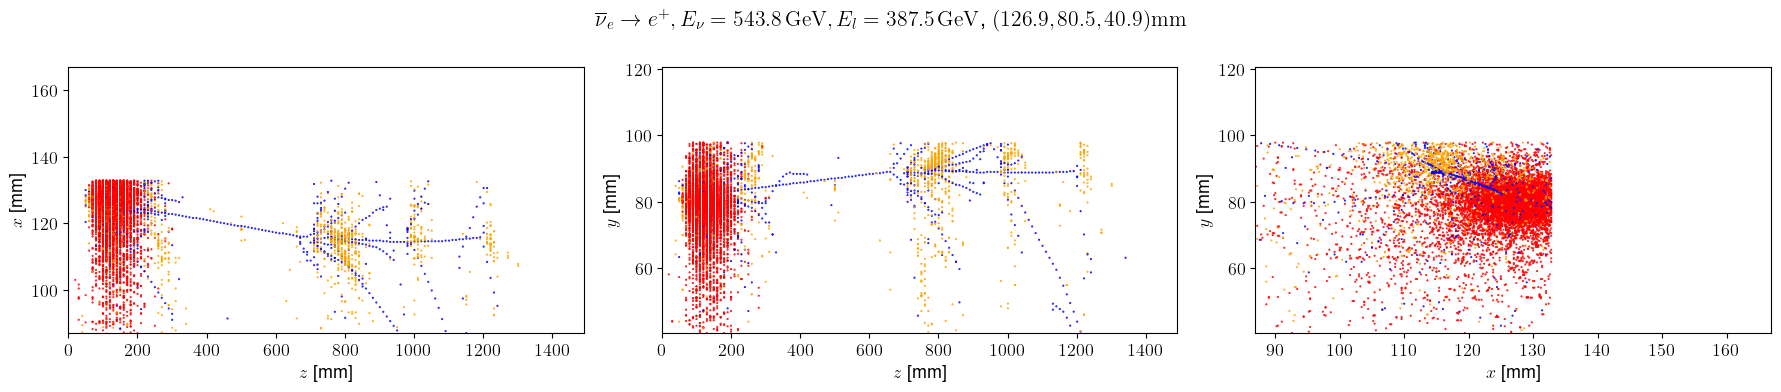

/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_hits.loc[:, "color"] = "blue"
/var/folders/cg/26x7gyxd1tv8lczyh55gc2cw0000gn/T/ipykernel_45582/3687972103.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend(loc="upper right")


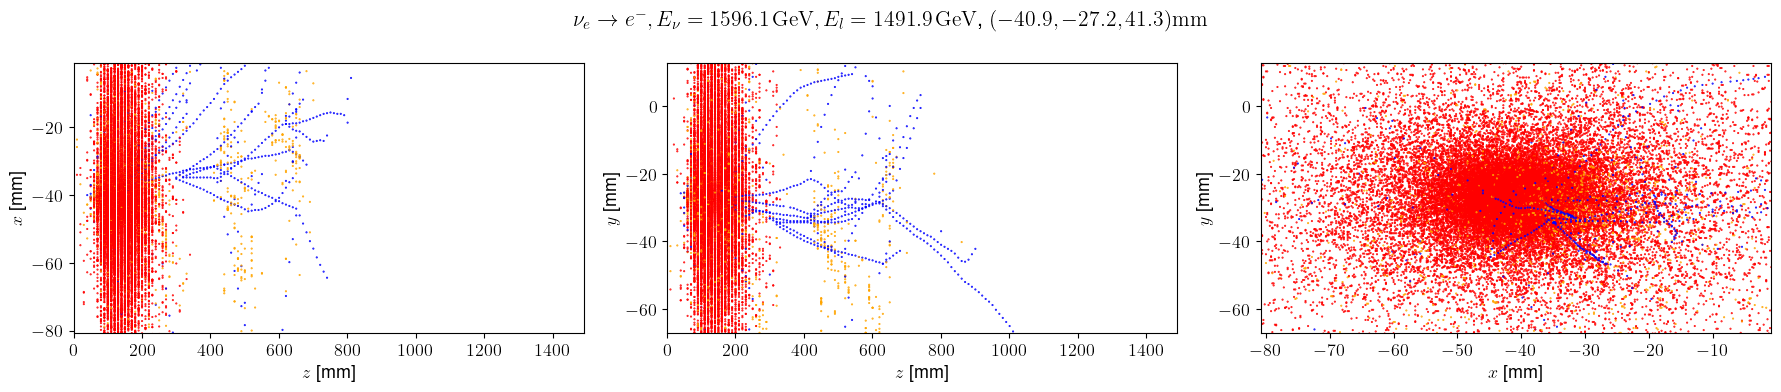

In [40]:
for event_id in range(5):
    plot_range = 40

    event_hits = hits_df.query(f"event_id == {event_id}")
    truth: TruthParticle = get_truth_particle(truth_df.query(f"event_id == {event_id}"))

    event_hits.loc[:, "color"] = "blue"
    for i, color in enumerate(["blue", "orange", "red", "green"]):
        event_hits.loc[event_hits["pdg_label"] == i, "color"] = color

    fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
    fig.suptitle(truth.get_latex_title())
    show_scatter_plots(
        df=event_hits,
        truth=truth,
        geo=geo,
        range=plot_range,
        axs=axs,
        color=event_hits["color"].values,
    )
    # for label, color in zip(latex_labels, colors):
    #     axs[0].scatter([], [], c=color, label=label)

    axs[0].legend(loc="upper right")
    plt.tight_layout()
    plt.show()

    # show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=plot_range)

In [213]:
pdg_colors = ["blue", "orange", "red", "green"]
latex_labels = [r"Primary $e^{\pm}$", r"Other $e^{\pm}$", r"$\mu^{\pm}$", r"Other"]
event_hits.loc[:, "color"] = "blue"
for i, color in enumerate(pdg_colors):
    event_hits.loc[event_hits["pdg_label"] == i, "color"] = color

In [ ]:
graph_data, means, stds = create_event_graph(
    hits_df=event_hits, layer_scale=1.0, k_neighbors=32
)

330.32500085599565 -126.6000005164876 8.399999776009992


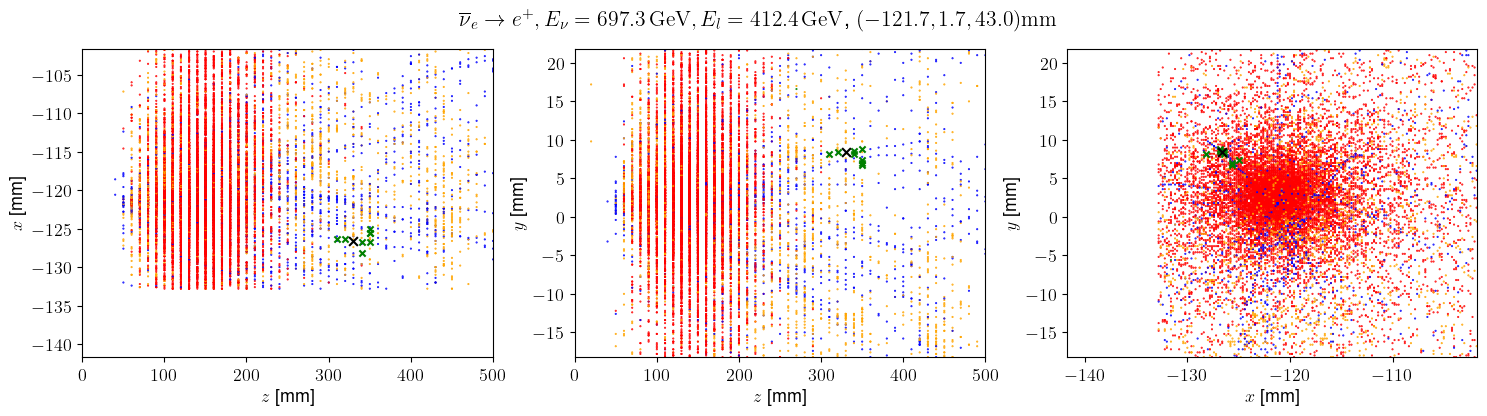

In [205]:
node_idx = 17400


nodes = graph_data.x.cpu().numpy() * stds + means
edges = graph_data.edge_index.cpu().numpy()
print(len(nodes), "nodes", len(edges[0]), "edges")
print(nodes[node_idx][2], nodes[node_idx][0], nodes[node_idx][1])

target_node_indices = edges[1][edges[0] == node_idx]
len(target_node_indices)

fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
fig.suptitle(truth.get_latex_title())
show_scatter_plots(
    df=event_hits,
    truth=truth,
    geo=geo,
    range=20,
    axs=axs,
    color=event_hits["color"].values,
    zlim=(0, 500),
)
for target in target_node_indices:
    axs[0].scatter(nodes[target][2], nodes[target][0], color="green", marker="x", s=20)
    axs[1].scatter(nodes[target][2], nodes[target][1], color="green", marker="x", s=20)
    axs[2].scatter(nodes[target][0], nodes[target][1], color="green", marker="x", s=20)
axs[0].scatter(nodes[node_idx][2], nodes[node_idx][0], color="black", marker="x", s=40)
axs[1].scatter(nodes[node_idx][2], nodes[node_idx][1], color="black", marker="x", s=40)
axs[2].scatter(nodes[node_idx][0], nodes[node_idx][1], color="black", marker="x", s=40)

18859 nodes 338667 edges
130.12499937652024 -122.40000024711581 -2.2410103328596165e-08
36


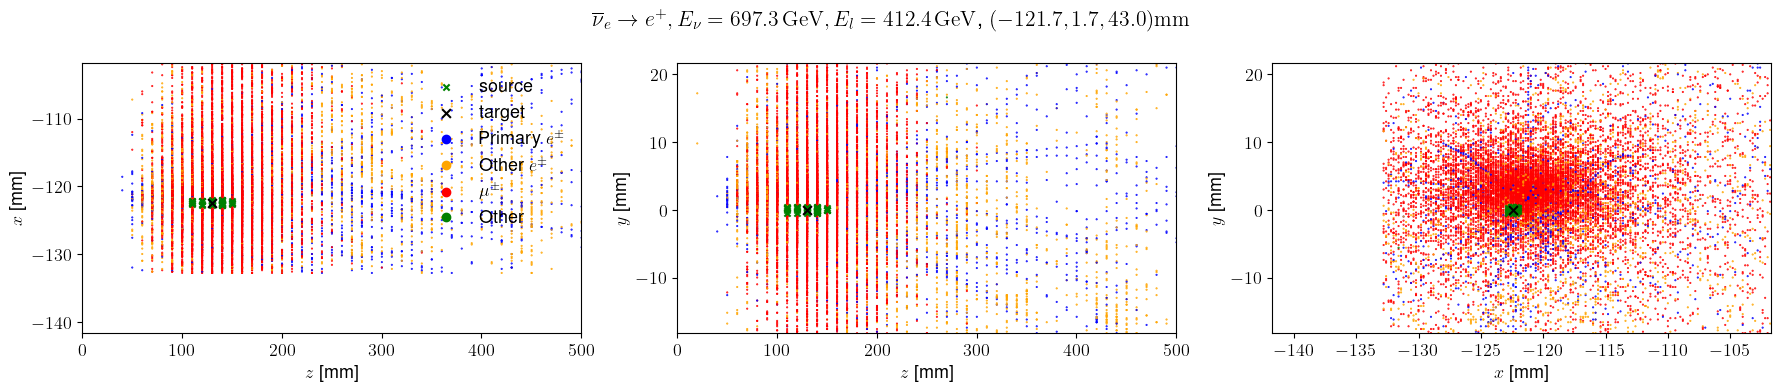

In [215]:
node_idx = 6000

nodes = graph_data.x.cpu().numpy() * stds + means
edges = graph_data.edge_index.cpu().numpy()
print(len(nodes), "nodes", len(edges[0]), "edges")
print(nodes[node_idx][2], nodes[node_idx][0], nodes[node_idx][1])

target_node_indices = edges[1][edges[0] == node_idx]
print(len(target_node_indices))

fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
fig.suptitle(truth.get_latex_title())
show_scatter_plots(
    df=event_hits,
    truth=truth,
    geo=geo,
    range=20,
    axs=axs,
    color=event_hits["color"].values,
    zlim=(0, 500),
)
for target in target_node_indices:
    axs[0].scatter(
        nodes[target][2],
        nodes[target][0],
        color="green",
        marker="x",
        s=20,
        label="source",
    )
    axs[1].scatter(nodes[target][2], nodes[target][1], color="green", marker="x", s=20)
    axs[2].scatter(nodes[target][0], nodes[target][1], color="green", marker="x", s=20)
axs[0].scatter(
    nodes[node_idx][2],
    nodes[node_idx][0],
    color="black",
    marker="x",
    s=40,
    label="target",
)
axs[1].scatter(nodes[node_idx][2], nodes[node_idx][1], color="black", marker="x", s=40)
axs[2].scatter(nodes[node_idx][0], nodes[node_idx][1], color="black", marker="x", s=40)

for label, color in zip(latex_labels, pdg_colors):
    axs[0].scatter([], [], c=color, label=label)

add_legend(axs[0], loc="upper right")
plt.tight_layout()
plt.show()

18859 nodes 338667 edges
330.32500085599565 -126.6000005164876 8.399999776009992
8


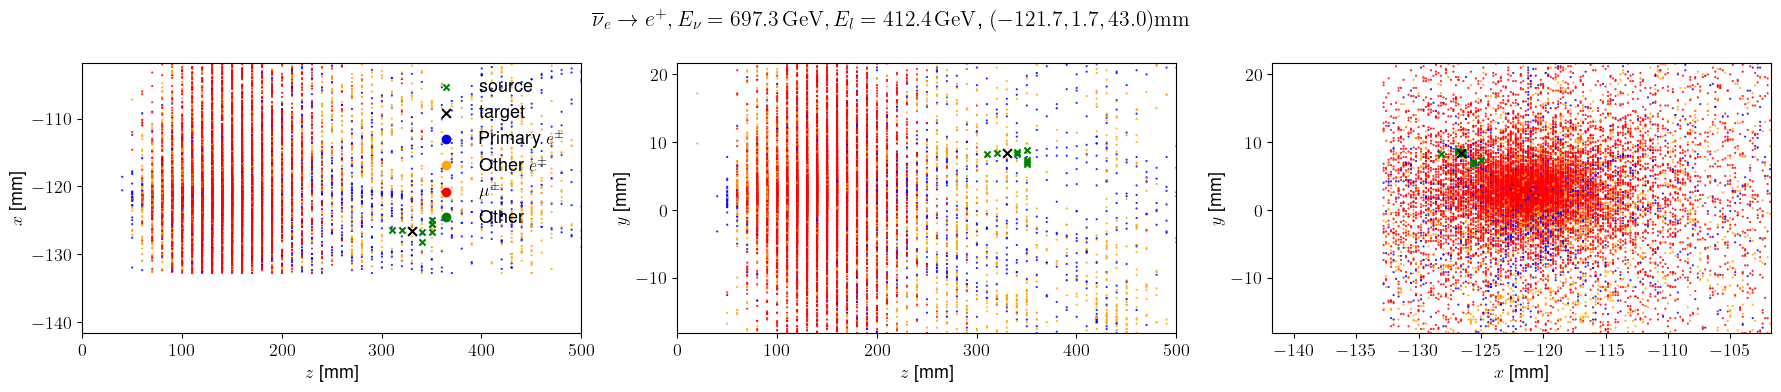

In [216]:
node_idx = 17400

nodes = graph_data.x.cpu().numpy() * stds + means
edges = graph_data.edge_index.cpu().numpy()
print(len(nodes), "nodes", len(edges[0]), "edges")
print(nodes[node_idx][2], nodes[node_idx][0], nodes[node_idx][1])

target_node_indices = edges[1][edges[0] == node_idx]
print(len(target_node_indices))

fig, axs = plt.subplots(1, 3, figsize=(6 * 3, 4))
fig.suptitle(truth.get_latex_title())
show_scatter_plots(
    df=event_hits,
    truth=truth,
    geo=geo,
    range=20,
    axs=axs,
    color=event_hits["color"].values,
    zlim=(0, 500),
)
for target in target_node_indices:
    axs[0].scatter(
        nodes[target][2],
        nodes[target][0],
        color="green",
        marker="x",
        s=20,
        label="source",
    )
    axs[1].scatter(nodes[target][2], nodes[target][1], color="green", marker="x", s=20)
    axs[2].scatter(nodes[target][0], nodes[target][1], color="green", marker="x", s=20)
axs[0].scatter(
    nodes[node_idx][2],
    nodes[node_idx][0],
    color="black",
    marker="x",
    s=40,
    label="target",
)
axs[1].scatter(nodes[node_idx][2], nodes[node_idx][1], color="black", marker="x", s=40)
axs[2].scatter(nodes[node_idx][0], nodes[node_idx][1], color="black", marker="x", s=40)

for label, color in zip(latex_labels, pdg_colors):
    axs[0].scatter([], [], c=color, label=label)

add_legend(axs[0], loc="upper right")
plt.tight_layout()
plt.show()

In [67]:
tmp = uproot.open("/Users/tboeckh/tmp/nu.99.gfaser.root")["gFaser"].arrays(library="pd")

## 200 um geometry


In [79]:
run = 10000
chunk = 2
root_path = get_root_path() / f"{run:05d}/{run:05d}_{chunk:03d}.root"
parquet_hits_path = get_parquet_path() / f"{run:05d}/{run:05d}_{chunk:03d}_hits.parq"
parquet_truth_path = get_parquet_path() / f"{run:05d}/{run:05d}_{chunk:03d}_truth.parq"
geometry_path = get_parquet_path() / f"{run:05d}/geometry.pkl"
geo_200um_path = get_parquet_path() / f"{run:05d}/muon_200um_bins/geometry_200um.pkl"

hits_df = pd.read_parquet(parquet_hits_path)
truth_df = pd.read_parquet(parquet_truth_path)
geo = get_geometry(geo_path=geometry_path)
geo_200um = get_rebinned_geometry(pixel_size=200 * um, old_geometry=geo)

In [80]:
hits_df.head()

event_id  hit_rowID  hit_colID  hit_layerID  hit_pdgc  \
entry subentry                                                          
0     0             2000       6246      10547            7       -11   
      1             2000       6457      10494            7       -11   
      2             2000       6850      10578            7        11   
      3             2000       6865      10622            7        11   
      4             2000       6612      10321            7       -11   

                hit_edep  hit_fromPrimaryLepton  hit_fromPrimaryEMShower  \
entry subentry                                                             
0     0         0.002084                  False                    False   
      1         0.003238                  False                    False   
      2         0.003269                  False                    False   
      3         0.001878                  False                    False   
      4         0.004681                  False                    False   

                      x        y       z  
entry subentry                            
0     0         86.3880  44.4202  80.075  
      1         85.2856  49.2310  80.075  
      2         87.0328  58.1914  80.075  
      3         87.9480  58.5334  80.075  
      4         81.6872  52.7650  80.075

In [47]:
event_id = 2000
event_hits = hits_df.query(f"event_id == {event_id}")

In [48]:
event_hits_200um = get_rebinned_df(event_hits, old_geometry=geo, new_geometry=geo_200um)

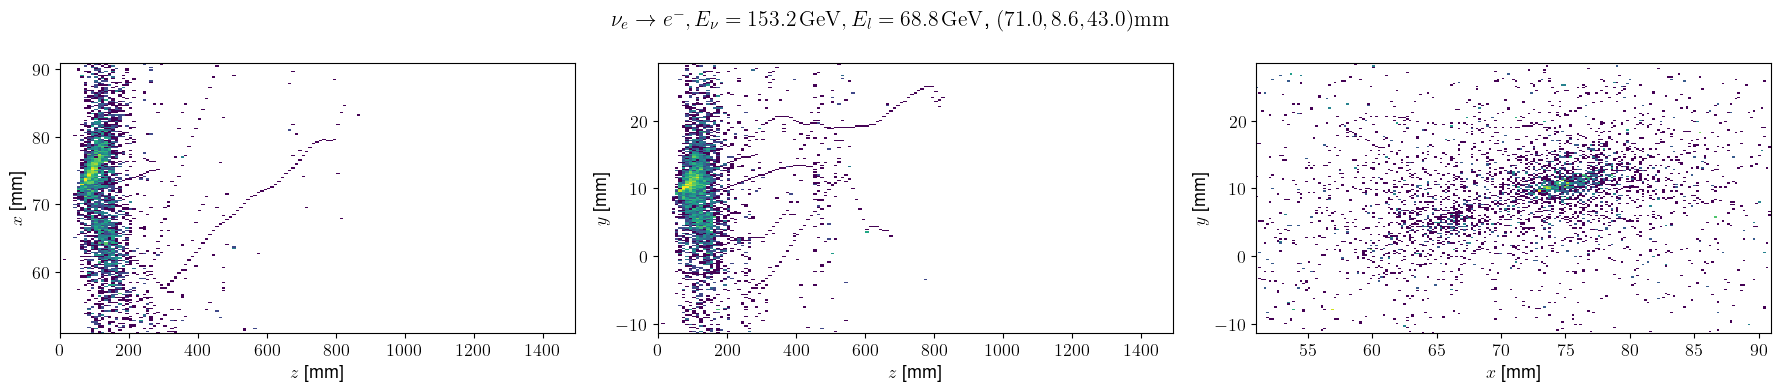

In [49]:
show_hist_plots(df=event_hits, truth=truth, geo=geo_200um, range=20)

In [78]:
np.stack([np.arange(3), np.arange(3)], axis=1)

array([[0, 0],
       [1, 1],
       [2, 2]])

In [86]:
np.vstack([np.arange(3), np.arange(3)]).T

array([[0, 0],
       [1, 1],
       [2, 2]])

In [77]:
event_hits[["x", "y", "z"]].values.T.shape

(3, 5289)

In [217]:
tmp = pd.read_parquet(
    "/Users/tboeckh/Documents/faser/neutrino-detector/data/parquet/10000/200um_bins/10000_000_hits.parq"
)

In [218]:
tmp.head()

,event_id,hit_layerID,pixel_x,pixel_y,energy,n_hits,pdg_label,x,y,z
index,,,,,,,,,,
0,0,1,1204,575,0.003979,1,1.0,108.0,17.2,20.015
1,0,1,1213,538,0.002115,1,1.0,109.8,9.8,20.015
2,0,2,246,726,0.010535,1,2.0,-83.6,47.4,30.025
3,0,2,307,681,0.003670,1,2.0,-71.4,38.4,30.025
4,0,2,307,682,0.004713,1,2.0,-71.4,38.6,30.025
